In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Load dataset
house = pd.read_csv('data.csv')

# Display first rows
print(house.head())

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [3]:
### Explore the Dataset

# Shape of dataset
print(house.shape)

# Column information
print(house.info())

# Summary statistics
print(house.describe())

(4600, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dt

In [5]:
## THIS HELPS US TO:

# Understand the size of the dataset.
# Detect missing values.
# Identify suspicious values.
# Understand numerical ranges.

In [4]:
## Find Physically Impossible Values

# Count houses with 0 bedrooms
zero_bedrooms = house[house['bedrooms'] == 0]

print(zero_bedrooms[['price', 'bedrooms', 'bathrooms']].head())
print('Number of homes with 0 bedrooms:', len(zero_bedrooms))

          price  bedrooms  bathrooms
2365  1095000.0       0.0        0.0
3209  1295648.0       0.0        0.0
Number of homes with 0 bedrooms: 2


In [6]:
# A home with zero bedrooms is not considered a standard functional residential property. 

# These values are likely:
# 1. Data entry errors
# 2. Missing information
# 3. Misclassified studio apartments

In [7]:
# Count houses with 0 bathrooms
zero_bathrooms = house[house['bathrooms'] == 0]

print(zero_bathrooms[['price', 'bedrooms', 'bathrooms']].head())
print('Number of homes with 0 bathrooms:', len(zero_bathrooms))

          price  bedrooms  bathrooms
2365  1095000.0       0.0        0.0
3209  1295648.0       0.0        0.0
Number of homes with 0 bathrooms: 2


In [8]:
## A residential property without a bathroom would not meet basic living standards.

#These values likely represent:

# Incorrect data collection
# Missing values entered as 0
# Incomplete records

In [9]:
# Remove impossible homes
house_clean = house[(house['bedrooms'] > 0) & (house['bathrooms'] > 0)]

print(house_clean.shape)

(4598, 18)


In [10]:
## Cleaning the dataset improves model quality because:

# Invalid records distort relationships.
# Regression models are sensitive to unrealistic values.
# Predictions become more accurate.

In [12]:
### Select Features and Target

# We will predict house price using:

# Bedrooms
# Bathrooms
# Square footage
# Floors
# Condition

X = house_clean[[
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'floors',
    'condition'
]]

# Target variable
y = house_clean['price']

In [15]:
## Split Data into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
## Training data teaches the model.
# Testing data evaluates performance on unseen data.
# 80% is used for training and 20% for testing.

In [18]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
# Predict house prices
predictions = model.predict(X_test)

print(predictions[:5])

[1129957.37241559  807817.95447055  449256.14823073  450670.81161696
  325477.88473153]


In [20]:
### Evaluate the Model 

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2 Score:', r2)


MAE: 201921.9012796774
RMSE: 906157.6302858384
R2 Score: 0.05470620506667967


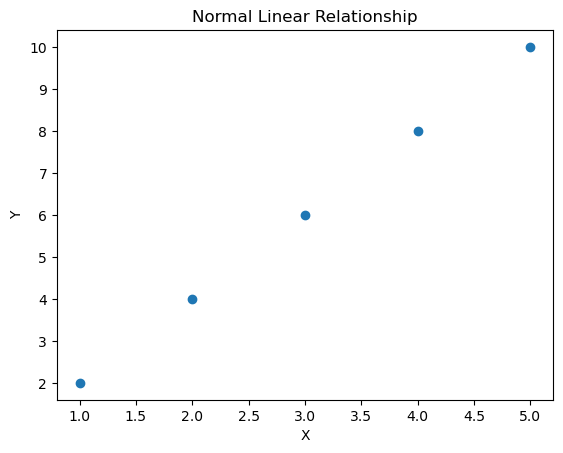

In [21]:
## Demonstration of Leverage Point Effect

# Sample data
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Plot
plt.scatter(x, y)
plt.title('Normal Linear Relationship')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


In [22]:
# The data follows a perfect straight-line pattern.
# The slope is stable because all points follow the same relationship.

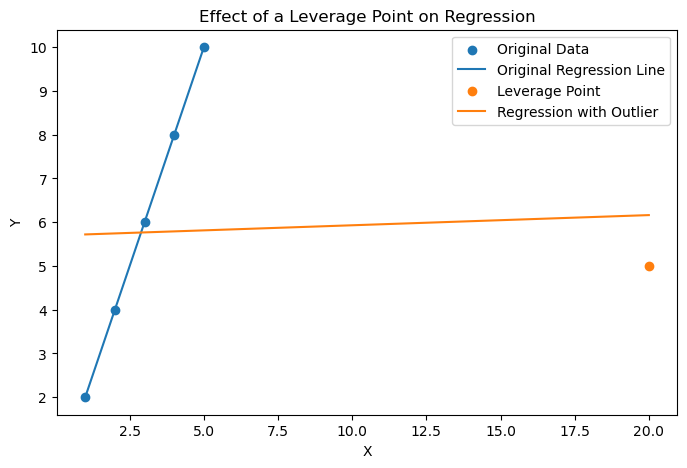

In [23]:
# Leverage Point added

# Add outlier
x_outlier = np.append(x, 20)
y_outlier = np.append(y, 5)

# Reshape for regression
X_normal = x.reshape(-1, 1)
X_outlier = x_outlier.reshape(-1, 1)

# Train models
model1 = LinearRegression()
model1.fit(X_normal, y)

model2 = LinearRegression()
model2.fit(X_outlier, y_outlier)

# Predictions for lines
line1 = model1.predict(X_normal)
line2 = model2.predict(X_outlier)

# Plot
plt.figure(figsize=(8,5))

plt.scatter(x, y, label='Original Data')
plt.plot(x, line1, label='Original Regression Line')

plt.scatter(x_outlier[-1], y_outlier[-1], label='Leverage Point')
plt.plot(x_outlier, line2, label='Regression with Outlier')

plt.legend()
plt.title('Effect of a Leverage Point on Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [24]:
## Before the Outlier

# The regression line fits the data perfectly.

# The slope is:

# Slope=2

# This means every increase of 1 in X increases Y by 2.

# After the Outlier

# The new point at:

# (20,5)

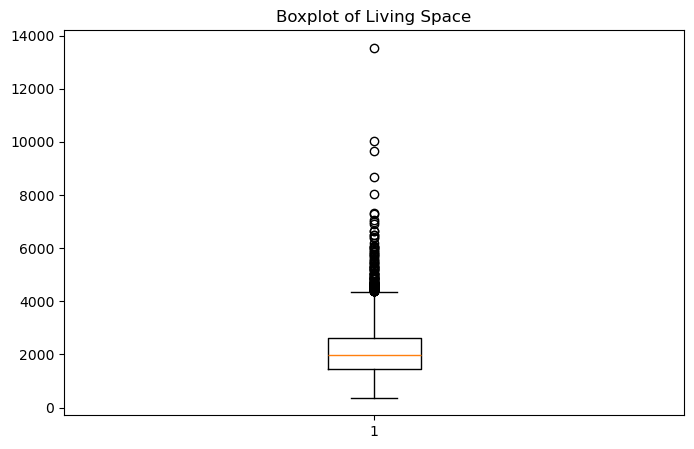

In [25]:
## Detecting Outliers in the Housing Dataset

# Visualize sqft_living
plt.figure(figsize=(8,5))
plt.boxplot(house_clean['sqft_living'])
plt.title('Boxplot of Living Space')
plt.show()

In [26]:
## The boxplot helps identify unusually large homes.
# Very large houses may act as leverage points and distort the regression line.

In [27]:
# Removing Extreme Outliers

Q1 = house_clean['sqft_living'].quantile(0.25)
Q3 = house_clean['sqft_living'].quantile(0.75)
IQR = Q3 - Q1

# Bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers
house_no_outliers = house_clean[
    (house_clean['sqft_living'] >= lower) &
    (house_clean['sqft_living'] <= upper)
]

print(house_no_outliers.shape)

(4470, 18)


In [28]:
# Removing extreme leverage points can:

# Improve regression accuracy
# Create a more stable slope
# Reduce prediction errors
# Prevent one observation from dominating the model

In [29]:
## CONCLUSION!!

# This project performed a complete regression pipeline on the raw housing dataset.

# Key findings:

# The dataset contained physically impossible values such as:
# Bedrooms = 0
# Bathrooms = 0
# Cleaning invalid records improved data quality.
# A linear regression model was trained to predict house prices.
# Leverage points strongly affect regression lines because linear regression minimizes squared errors.
# Extreme outliers can significantly change the slope and reduce model accuracy.
# Detecting and handling outliers is an important part of data preprocessing in machine learning.

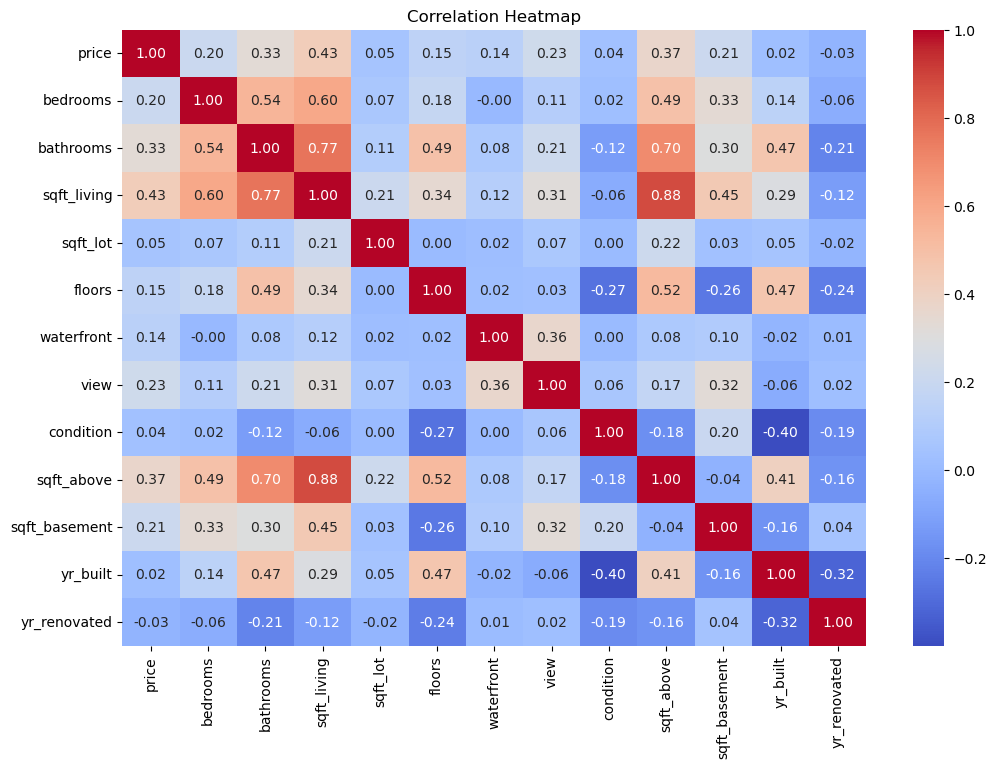

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numeric_data = house_clean.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [31]:
# Check Correlation with the Target Variable

# Correlation with price
price_corr = corr_matrix['price'].sort_values(ascending=False)

print(price_corr[['sqft_living', 'sqft_above']])

sqft_living    0.429941
sqft_above     0.366943
Name: price, dtype: float64


In [33]:
# drop sqft_above and keep sqft_living

# Drop highly correlated feature
house_reduced = house_clean.drop(columns=['sqft_above'])

print(house_reduced.head())

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_basement  yr_built  yr_renovated  \
0     1.5           0     0          3              0      1955          2005   
1     2.0           0     4          5            280      1921             0   
2     1.0           0     0          4              0      1966             0   
3     1.0           0     0          4           1000      1963             0   
4     1.0           0     0          4            800      1976          1992   

                     stree

In [34]:
## Performance Stress Test

# This section checks how well the regression model performs.

# We will calculate:

# MAE
# RMSE
# R² Score

# We will also:

# Explain why RMSE reacts more to large errors
# Create a Residual Plot

In [35]:
# Calculate MAE, RMSE, and R²

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Make predictions
predictions = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

# Print results
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 201921.9012796774
RMSE: 906157.6302858384
R² Score: 0.05470620506667967


In [39]:
# MAE Formula
# MAE=n1​∑∣yi​−yi​^​∣

# MAE uses absolute values.

# Every error is treated equally.
# Example:

# Error of 10 = contributes 10
# Error of 100 = contributes 100

# RMSE Formula
# RMSE= sqroot[n1​∑(yi​−yi​^​)2]
# RMSE squares the errors before averaging.

# This makes large mistakes much bigger.

# Example:

# Error of 10 → becomes 100
# Error of 100 → becomes 10,000

# Because of squaring:

# Large errors dominate the calculation.
# RMSE becomes very sensitive to outliers.

# MAE
# Treats all mistakes fairly.

# RMSE
# Punishes big mistakes much more strongly.

In [40]:
# Create a Residual Plot

# Residuals:

# Residual=Actual−Predicted

# A residual plot helps us see:

# If the model performs equally across all house prices
# Whether expensive homes are harder to predict

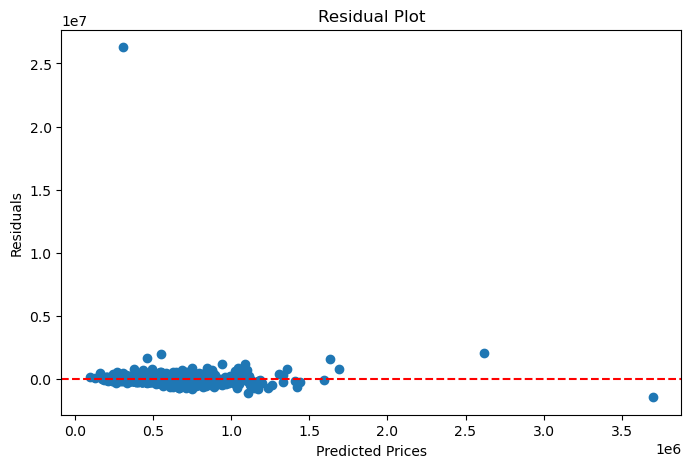

In [41]:
import matplotlib.pyplot as plt

# Residuals
residuals = y_test - predictions

# Plot
plt.figure(figsize=(8,5))

plt.scatter(predictions, residuals)

# Horizontal reference line
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')

plt.title('Residual Plot')

plt.show()